In [19]:
import pickle
import time
import os
import re
import pprint
import random
import numpy as np

from autqec.automorphisms   import *
from autqec.utils.qec       import *
from autqec.utils.qiskit    import *
from autqec.graph_auts      import *
from autqec.ZX_dualities    import *
from autqec.ZY_dualities    import *
from autqec.magma_interface import *
from autqec.code_embedding  import *

from magma_online import *

In [ ]:
# Helpers to find automorphisms from online magma software

import re
import numpy as np

from urllib.parse       import urlencode
from http.client        import HTTPSConnection
from xml.dom.minidom    import parseString

def run_magma_online_from_file(command_file):
    match = re.search(r"n(\d+)k(\d+)d(\d+)", command_file)
    if not match:
        raise ValueError(f"Could not parse n,k,d from {command_file}")

    n, k, d = match.groups()
    output_file = f"magma_output_n{n}k{k}d{d}.txt"

    with open(command_file, "r") as f:
        code = f.read()

    code = "SetColumns(0);\n" + code

    params = urlencode({"input": code})
    headers = {
        "Content-type": "application/x-www-form-urlencoded",
        "Accept": "application/xml,text/xml,*/*",
        "Referer": "https://magma.maths.usyd.edu.au/calc/",
        "User-Agent": "Mozilla/5.0",
    }

    conn = HTTPSConnection("magma.maths.usyd.edu.au", timeout=120)
    conn.request("POST", "/xml/calculator.xml", params, headers)
    response = conn.getresponse()

    raw = response.read()
    status = response.status
    content_type = response.getheader("Content-Type")
    conn.close()

    # Save raw response for debugging
    with open("magma_raw_response.txt", "wb") as f:
        f.write(raw)

    if status != 200:
        raise RuntimeError("Magma server did not return HTTP 200.")

    # Check if response is actually XML
    stripped = raw.lstrip()
    if not stripped.startswith(b"<?xml") and not stripped.startswith(b"<results"):
        raise RuntimeError(
            "Magma server returned non-XML. "
            "Check magma_raw_response.txt to see the actual response."
        )

    xml_doc = parseString(raw)

    result_lines = []

    for results in xml_doc.getElementsByTagName("results"):
        for line in results.getElementsByTagName("line"):
            text = "".join(
                node.data
                for node in line.childNodes
                if node.nodeType == node.TEXT_NODE
            )
            result_lines.append(text)

    output = "\n".join(result_lines)

    with open(output_file, "w") as f:
        f.write(output)


def parse_magma_output(magma_output_filename, qec_code_auts_from_magma_with_intersection_obj):
    with open(magma_output_filename, "r") as file:
        raw_magma_output = file.read()

    # time
    time_pattern = r"Time:\s*([\d\.]+)"
    match = re.search(time_pattern, raw_magma_output)
    if match:
        time = float(match.group(1))
    else:
        time = 0.0
    
    # automorphism group order
    order_pattern = r"Order:\s*(\d+)"
    match = re.search(order_pattern, raw_magma_output)
    if match:
        order = int(match.group(1))
    else:
        order = 1

    # automorphism group generators and qubit relabelling to original basis
    reordered_qubit_list, H_rref, transform_rows, transform_cols = qec_code_auts_from_magma_with_intersection_obj.preprocess_H_3bit()
    aut_gens, aut_gens_text = qec_code_auts_from_magma_with_intersection_obj.parse_magma_output_for_aut_gens(raw_magma_output)
    fixed_auts_gens = []
    for g in aut_gens:
        correct_g = []
        for cycle in g:
            new_cycle = []
            for i in cycle:
                new_cycle.append(reordered_qubit_list[i-1])
            correct_g.append(tuple(new_cycle))
        fixed_auts_gens.append(correct_g)

    # store in dictionary
    code_auts_dict = {}
    code_auts_dict['order'] = order
    code_auts_dict['auts'] = fixed_auts_gens
    code_auts_dict['time'] = time

    return code_auts_dict


# Try to combine two 5-qubit codes
Single Ancilla to get cz between qubits 1 and 6

In [ ]:
n_og = 10 

n = 10
k = 2 
d = 3

stabs_block1 = ['XZZXIIIIII','IXZZXIIIII','XIXZZIIIII','ZXIXZIIIII']
stabs_block2 = ['IIIIIXZZXI','IIIIIIXZZX','IIIIIXIXZZ','IIIIIZXIXZ']

H_symp = stabs_to_H_symp(stabs_block1 + stabs_block2)

In [31]:
embed_codespace_dict = {1: (1, 6)}
I = np.eye(n_og, dtype=int)

aux_row = np.zeros((1, n_og), dtype=int)
aux_row[0, 1-1] = 1
aux_row[0, 6-1] = 1
custom_embedding_mat = np.vstack([I, aux_row])

H_symp_embedded = qec_embed_code(H_symp, embedding="custom", custom_embedding=custom_embedding_mat).embed_mat()

n_embedded = H_symp_embedded.shape[1] // 2
print(H_symp_embedded.shape)

(9, 22)


In [32]:
command_file_name    = f"magma_commands_n{n_embedded}k{k}d{d}.txt"
output_file_name     = f"magma_output_n{n_embedded}k{k}d{d}.txt"
with open(output_file_name, "w") as output_file:
        pass

# magma_obj = qec_code_auts_from_magma_with_intersection(n, k, d, H_symp_embedded)
magma_obj = qec_code_auts_from_magma(n_embedded, k, d, H_symp_embedded)
magma_obj.run(fileroot='./',save_magma_commands=True)

run_magma_online_from_file(command_file_name)
code_auts_dict = parse_magma_output(output_file_name, magma_obj)

print('Aut Group Order: ', code_auts_dict['order'])
print('Time: ', code_auts_dict['time'])
print('No of aut gens: ', len(code_auts_dict['auts']))

Run the commands on MAGMA online calculator.
Copy and save output as 'magma_output_n11k2d3.txt'

Aut Group Order:  1152
Time:  0.02
No of aut gens:  7


In [33]:
auts = code_auts_dict['auts']
circuits = []
for num, aut in enumerate(auts):
    phys_act = circ_from_aut(H_symp_embedded,aut)        
    phys_circ, _ = phys_act.circ()
    log_act, circ = logical_circ_and_pauli_correct(H_symp_embedded,phys_circ).run()
    circuits.append((log_act,circ))

embedded physical circuit: [('Z', 1), ('Z', 3), ('Y', 5), ('Z', 6), ('Z', 7), ('Z', 8), ('X', 10), ('S', 1), ('S', 2), ('Xsqrt', 3), ('H', 4), ('Xsqrt', 5), ('S', 6), ('Xsqrt', 7), ('H', 8), ('Xsqrt', 9), ('S', 10), ('SWAP', (8, 10)), ('SWAP', (7, 9)), ('SWAP', (5, 8)), ('SWAP', (4, 9)), ('SWAP', (3, 10)), ('SWAP', (2, 7)), ('SWAP', (1, 6))]
normal physical circuit:   [('Z', 1), ('Z', 3), ('Y', 5), ('Z', 6), ('Z', 7), ('Z', 8), ('X', 10), ('S', 1), ('S', 2), ('Xsqrt', 3), ('H', 4), ('Xsqrt', 5), ('S', 6), ('Xsqrt', 7), ('H', 8), ('Xsqrt', 9), ('S', 10), ('SWAP', (8, 10)), ('SWAP', (7, 9)), ('SWAP', (5, 8)), ('SWAP', (4, 9)), ('SWAP', (3, 10)), ('SWAP', (2, 7)), ('SWAP', (1, 6))]
logical action:            [('H', 1), ('H', 2), ('SWAP', (2, 1))]


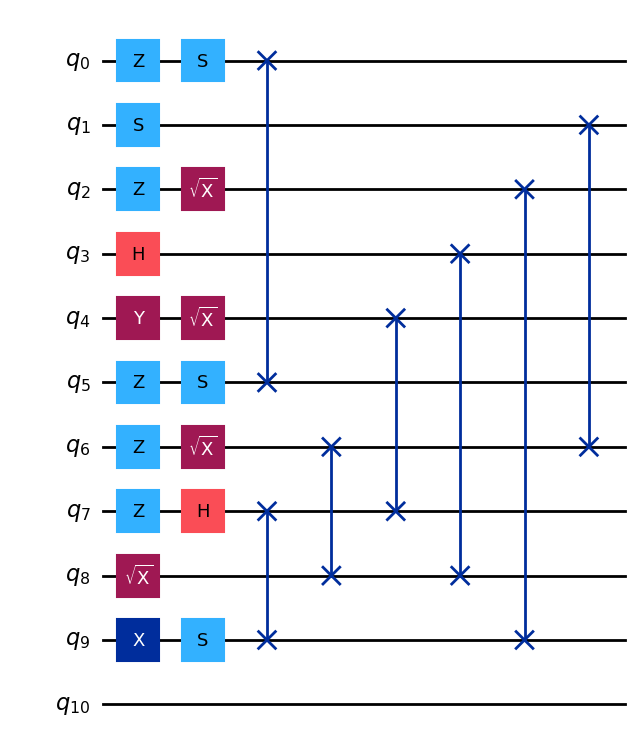

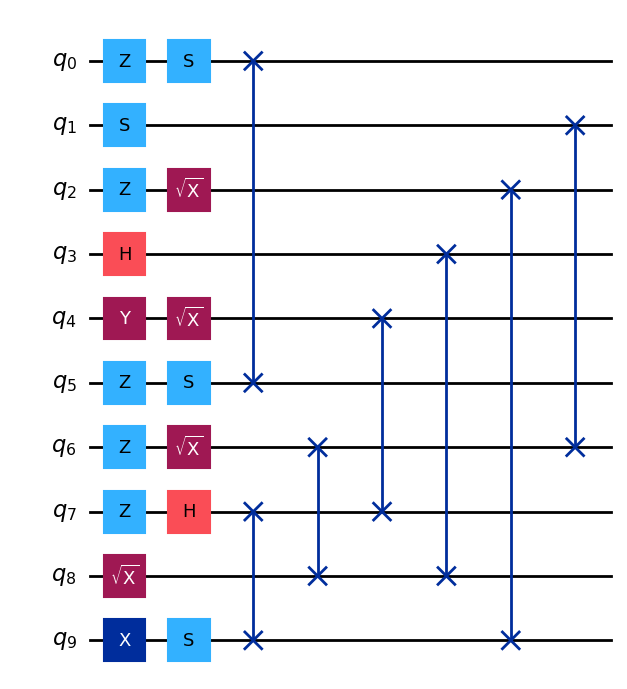

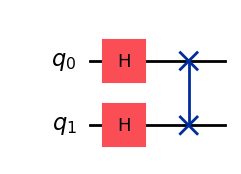



embedded physical circuit: [('Z', 7), ('Z', 8), ('Z', 9), ('Z', 10), ('S', 6), ('H', 7), ('Xsqrt', 8), ('Xsqrt', 9), ('H', 10), ('SWAP', (8, 9))]
normal physical circuit:   [('Z', 7), ('Z', 8), ('Z', 9), ('Z', 10), ('S', 6), ('H', 7), ('Xsqrt', 8), ('Xsqrt', 9), ('H', 10), ('SWAP', (8, 9))]
logical action:            [('S', 2)]


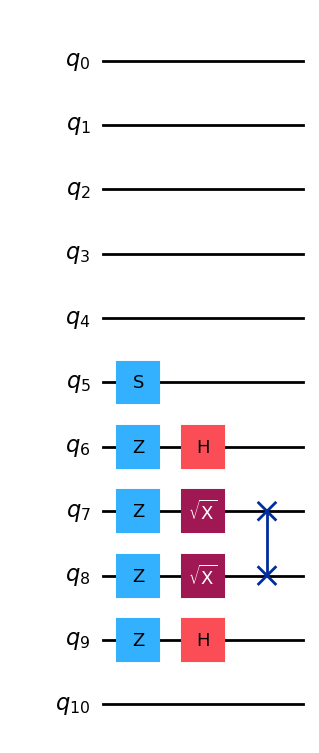

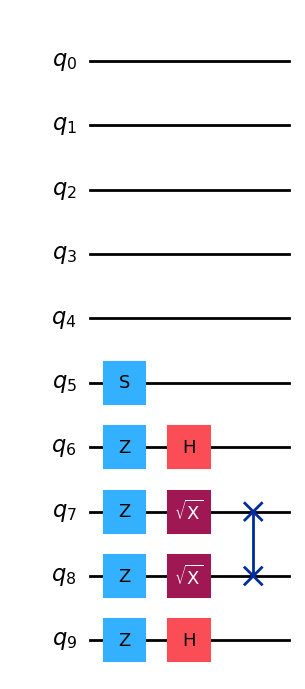

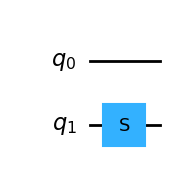



embedded physical circuit: [('GammaXZY', 2), ('GammaXYZ', 3), ('GammaXYZ', 4), ('GammaXZY', 5), ('SWAP', (3, 5)), ('SWAP', (2, 4))]
normal physical circuit:   [('GammaXZY', 2), ('GammaXYZ', 3), ('GammaXYZ', 4), ('GammaXZY', 5), ('SWAP', (3, 5)), ('SWAP', (2, 4))]
logical action:            []


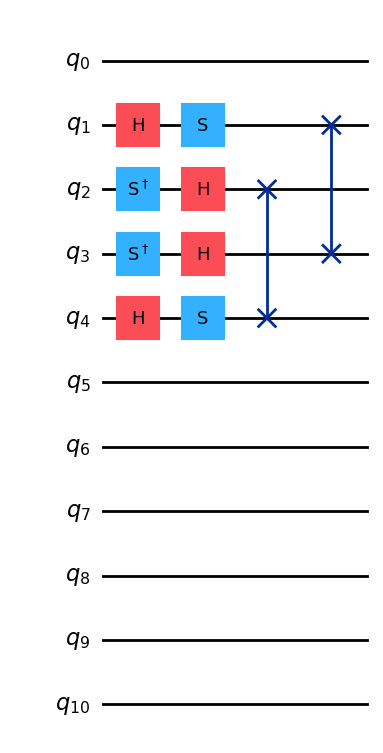

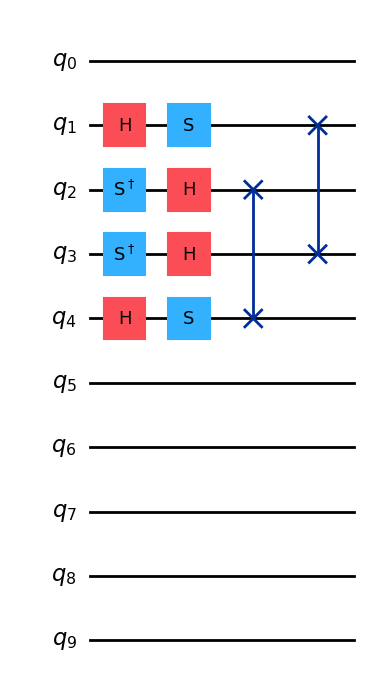

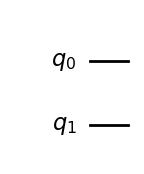



embedded physical circuit: [('Z', 1), ('Z', 4), ('S', 1), ('H', 2), ('H', 3), ('S', 4), ('Xsqrt', 5), ('SWAP', (2, 3))]
normal physical circuit:   [('Z', 1), ('Z', 4), ('S', 1), ('H', 2), ('H', 3), ('S', 4), ('Xsqrt', 5), ('SWAP', (2, 3))]
logical action:            [('Xsqrt', 1)]


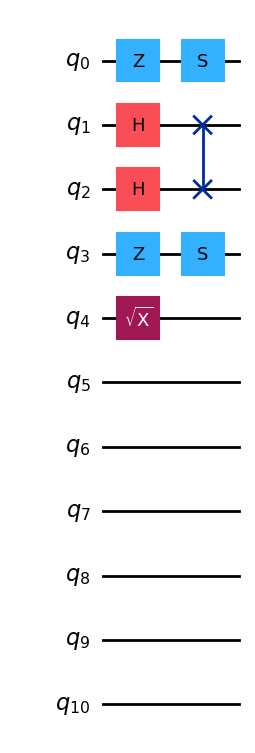

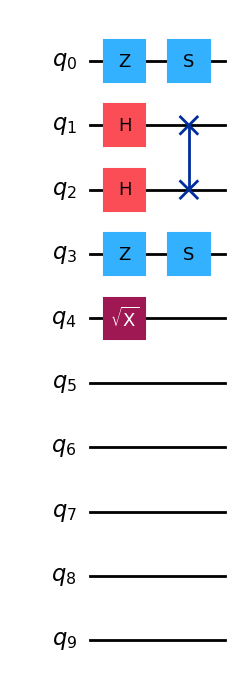

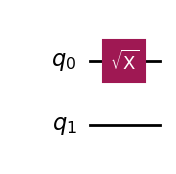



embedded physical circuit: [('Z', 7), ('Z', 8), ('Z', 9), ('Z', 10), ('S', 6), ('H', 7), ('Xsqrt', 8), ('Xsqrt', 9), ('H', 10), ('SWAP', (7, 10))]
normal physical circuit:   [('Z', 7), ('Z', 8), ('Z', 9), ('Z', 10), ('S', 6), ('H', 7), ('Xsqrt', 8), ('Xsqrt', 9), ('H', 10), ('SWAP', (7, 10))]
logical action:            [('S', 2)]


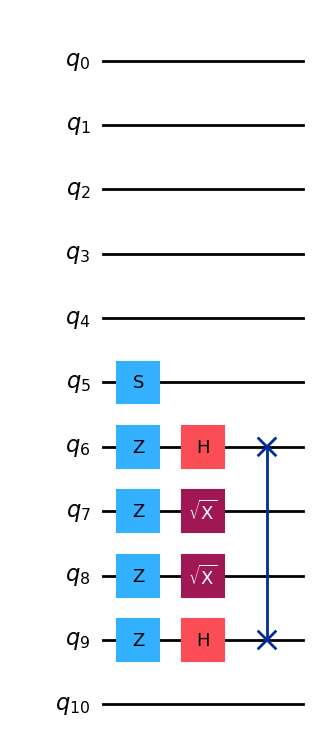

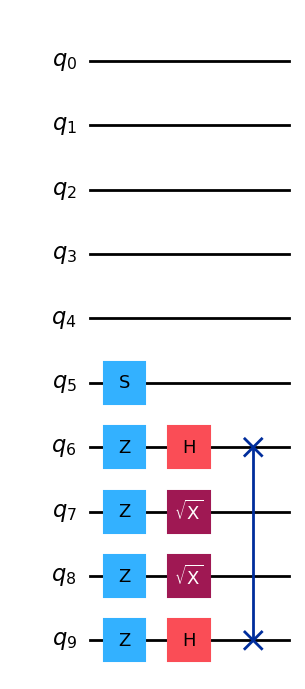

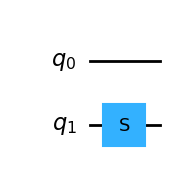



embedded physical circuit: [('Z', 2), ('Z', 3), ('Y', 5), ('GammaXYZ', 2), ('GammaXZY', 3), ('GammaXYZ', 4), ('SWAP', (4, 5)), ('SWAP', (3, 5))]
normal physical circuit:   [('Z', 2), ('Z', 3), ('Y', 5), ('GammaXYZ', 2), ('GammaXZY', 3), ('GammaXYZ', 4), ('SWAP', (4, 5)), ('SWAP', (3, 5))]
logical action:            [('S', 1), ('Xsqrt', 1)]


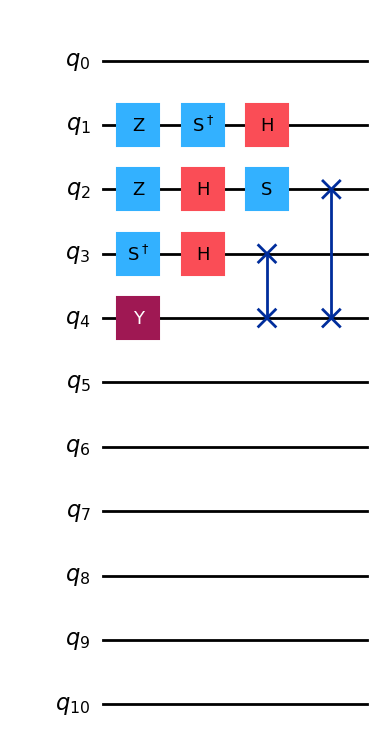

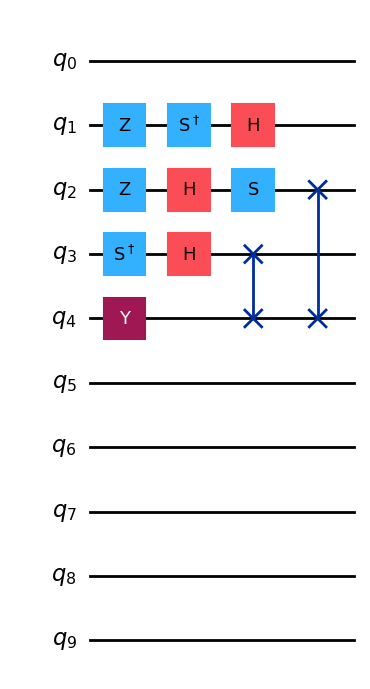

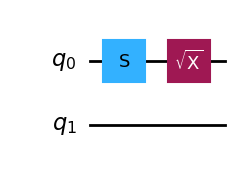



embedded physical circuit: [('Z', 6), ('Z', 9), ('X', 10), ('GammaXYZ', 7), ('GammaXZY', 9), ('GammaXZY', 10), ('SWAP', (8, 10)), ('SWAP', (7, 8))]
normal physical circuit:   [('Z', 6), ('Z', 9), ('X', 10), ('GammaXYZ', 7), ('GammaXZY', 9), ('GammaXZY', 10), ('SWAP', (8, 10)), ('SWAP', (7, 8))]
logical action:            [('H', 2), ('Xsqrt', 2)]


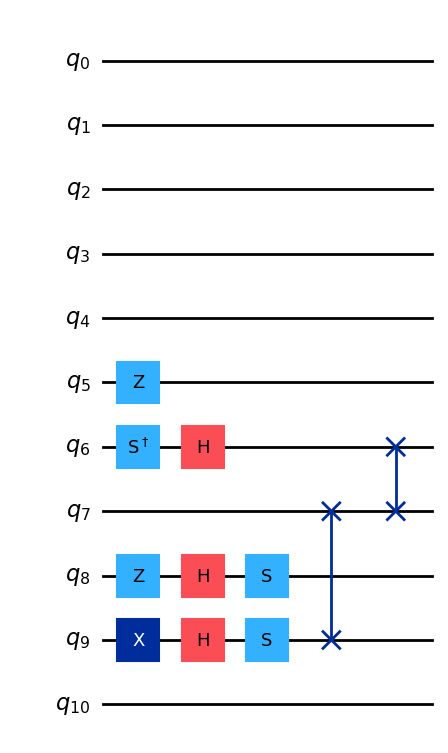

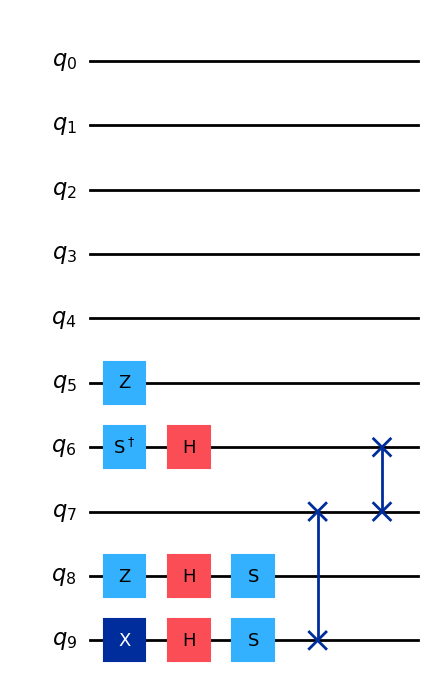

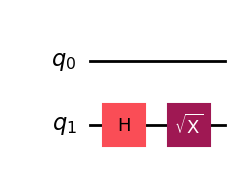

In [34]:
for _, phys_circ in circuits:
    normal_circ  = embed_circ_to_normal_circ(phys_circ, n_og, embed_codespace_dict)
    try:
        log_act = logical_circ_and_pauli_correct(H_symp, normal_circ).run()[0]
        print("embedded physical circuit:", phys_circ)
        print("normal physical circuit:  ", normal_circ)
        print("logical action:           ", log_act)
        display(construct_circuit(phys_circ, n_embedded).draw(output='mpl'))
        display(construct_circuit(normal_circ, n_og).draw(output='mpl'))
        display(construct_circuit(log_act, k).draw(output='mpl'))
        print("\n"+80*"=" +"\n")
    except:
        print("embedded physical circuit:", phys_circ)
        print("normal physical circuit:  ", normal_circ)
        print("logical action:           "+ "COULD NOT FIND (circuit doesn't map to smaller space)")
        display(construct_circuit(phys_circ, n_embedded).draw(output='mpl'))
        display(construct_circuit(normal_circ, n_og).draw(output='mpl'))
        print("\n"+80*"=" +"\n")
        continue

## Embedd to allow CZ's between (1,6), (2,7), (3,8), (4,9), (5,10)

In [35]:
embed_codespace_dict = {1: (1,6),   # first ancilla qubit is cnot between 1 and 6
                        2: (2,7),
                        3: (3,8),
                        4: (4,9),
                        5: (5,10)}

In [36]:
H_symp_embedded = qec_embed_code(H_symp, embedding = "two_code_blocks").embed_mat()
n_embedded = H_symp_embedded.shape[1]//2
print(H_symp_embedded.shape)

(13, 30)


In [37]:
G, LX, LZ, D = compute_standard_form(H_symp_embedded)

In [38]:
command_file_name    = f"magma_commands_n{n_embedded}k{k}d{d}.txt"
output_file_name     = f"magma_output_n{n_embedded}k{k}d{d}.txt"
with open(output_file_name, "w") as output_file:
        pass

# magma_obj = qec_code_auts_from_magma_with_intersection(n, k, d, H_symp_embedded)
magma_obj = qec_code_auts_from_magma(n_embedded, k, d, H_symp_embedded)
magma_obj.run(fileroot='./',save_magma_commands=True)

run_magma_online_from_file(command_file_name)
code_auts_dict = parse_magma_output(output_file_name, magma_obj)

print('Aut Group Order: ', code_auts_dict['order'])
print('Time: ', code_auts_dict['time'])
print('No of aut gens: ', len(code_auts_dict['auts']))

Run the commands on MAGMA online calculator.
Copy and save output as 'magma_output_n15k2d3.txt'

Aut Group Order:  40
Time:  0.04
No of aut gens:  3


In [39]:
auts = code_auts_dict['auts']
circuits = []
for num, aut in enumerate(auts):
    phys_act = circ_from_aut(H_symp_embedded,aut)        
    phys_circ, _ = phys_act.circ()
    log_act, circ = logical_circ_and_pauli_correct(H_symp_embedded,phys_circ).run()
    circuits.append((log_act,circ))

embedded physical circuit: [('SWAP', (5, 10)), ('SWAP', (4, 9)), ('SWAP', (3, 8)), ('SWAP', (2, 7)), ('SWAP', (1, 6))]
normal physical circuit:   [('SWAP', (5, 10)), ('SWAP', (4, 9)), ('SWAP', (3, 8)), ('SWAP', (2, 7)), ('SWAP', (1, 6))]
logical action:            [('SWAP', (2, 1))]


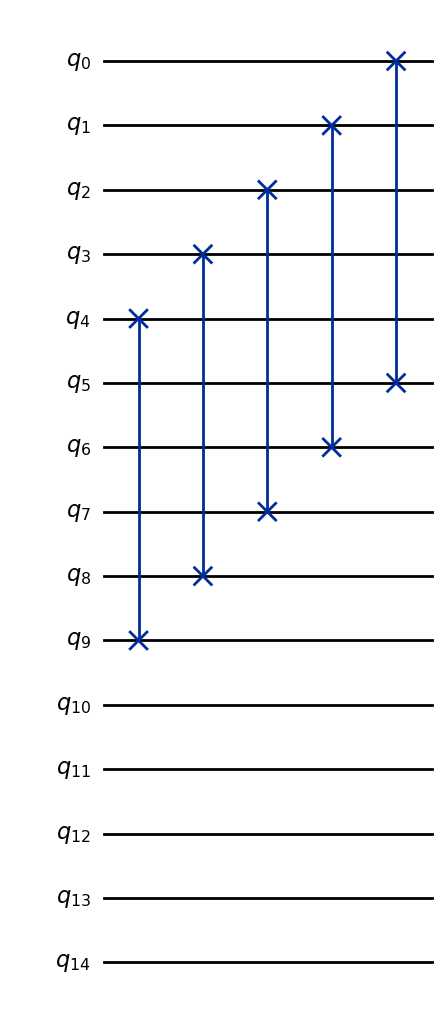

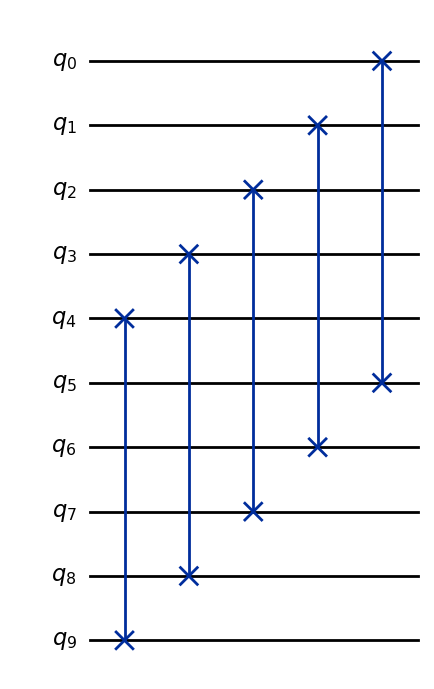

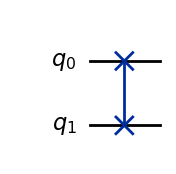



embedded physical circuit: [('Z', 6), ('Z', 7), ('Z', 8), ('Z', 9), ('Z', 10), ('S', 1), ('S', 2), ('S', 3), ('S', 4), ('S', 5), ('S', 6), ('S', 7), ('S', 8), ('S', 9), ('S', 10), ('SWAP', (14, 15)), ('SWAP', (13, 14)), ('SWAP', (12, 14)), ('SWAP', (8, 9)), ('SWAP', (7, 10)), ('SWAP', (5, 8)), ('SWAP', (4, 10)), ('SWAP', (3, 7)), ('SWAP', (2, 9)), ('SWAP', (1, 6))]
normal physical circuit:   [('Z', 6), ('Z', 7), ('Z', 8), ('Z', 9), ('Z', 10), ('S', 1), ('S', 2), ('S', 3), ('S', 4), ('S', 5), ('S', 6), ('S', 7), ('S', 8), ('S', 9), ('S', 10), ('CNOT', (9, 4)), ('CNOT', (10, 5)), ('SWAP', (4, 5)), ('CNOT', (9, 4)), ('CNOT', (10, 5)), ('CNOT', (8, 3)), ('CNOT', (9, 4)), ('SWAP', (3, 4)), ('CNOT', (8, 3)), ('CNOT', (9, 4)), ('CNOT', (7, 2)), ('CNOT', (9, 4)), ('SWAP', (2, 4)), ('CNOT', (7, 2)), ('CNOT', (9, 4)), ('SWAP', (8, 9)), ('SWAP', (7, 10)), ('SWAP', (5, 8)), ('SWAP', (4, 10)), ('SWAP', (3, 7)), ('SWAP', (2, 9)), ('SWAP', (1, 6))]
logical action:           COULD NOT FIND (circuit 

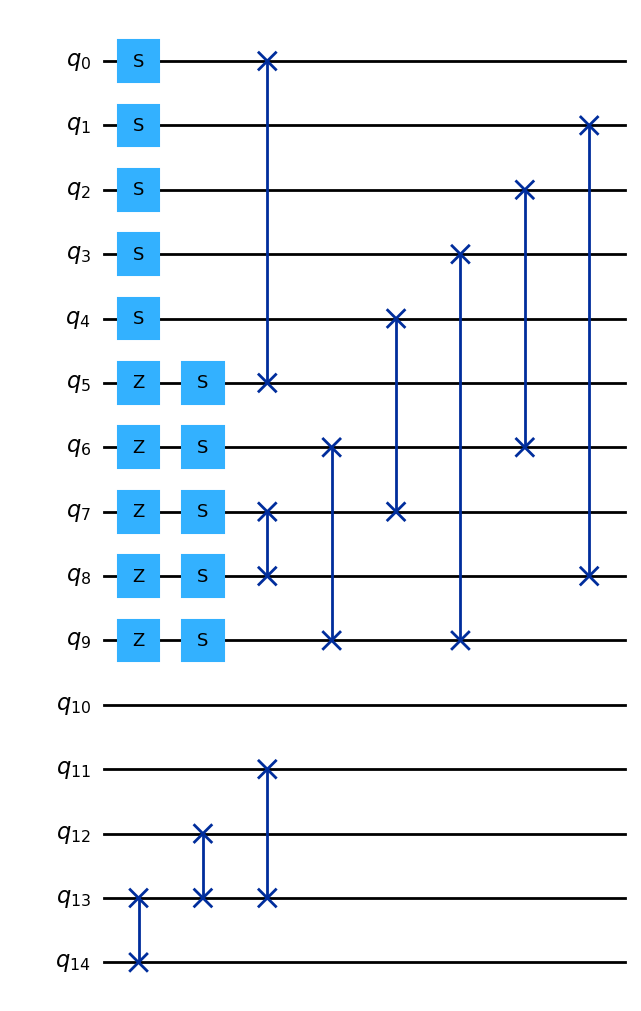

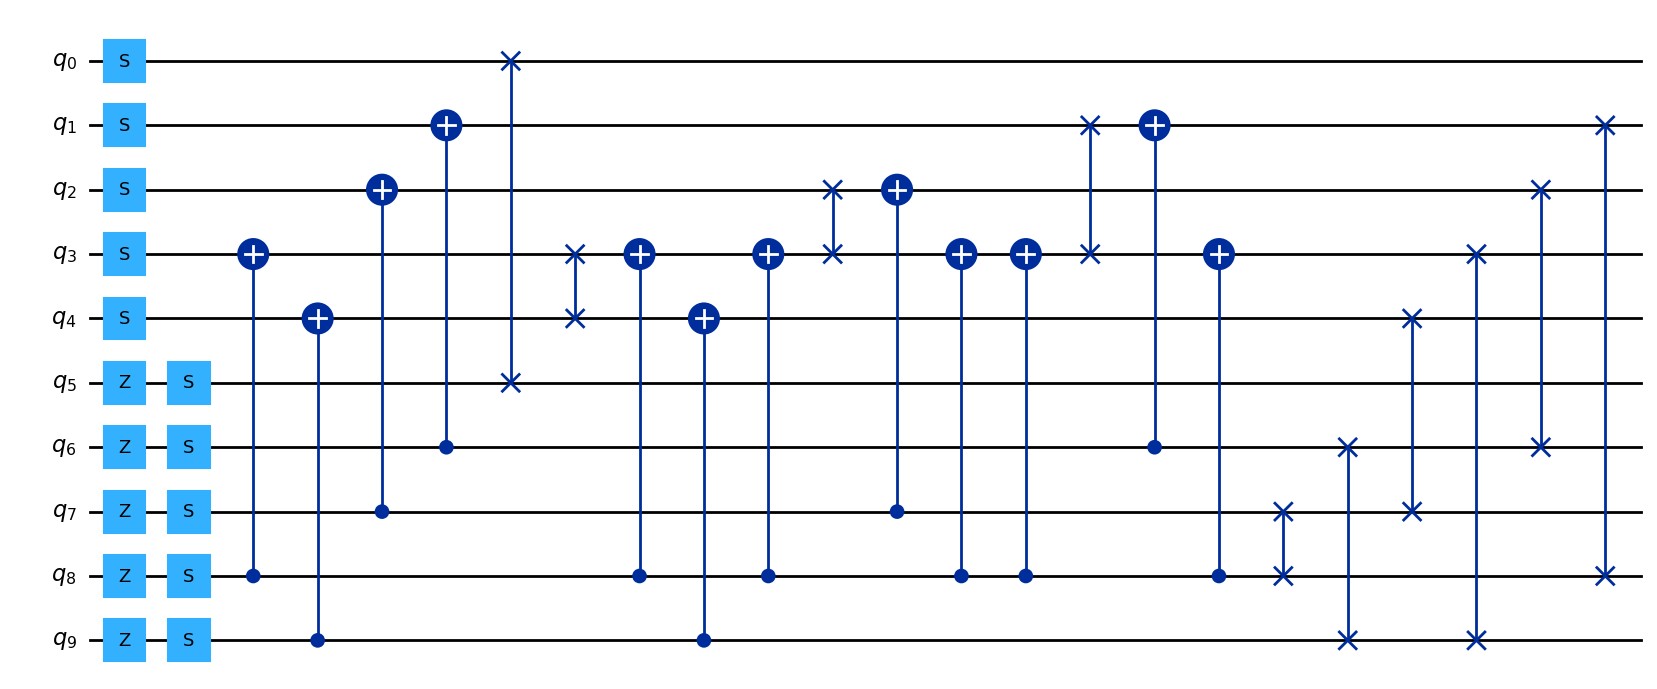



embedded physical circuit: [('SWAP', (14, 15)), ('SWAP', (13, 15)), ('SWAP', (12, 14)), ('SWAP', (11, 13)), ('SWAP', (9, 10)), ('SWAP', (8, 10)), ('SWAP', (7, 9)), ('SWAP', (6, 8)), ('SWAP', (4, 5)), ('SWAP', (3, 5)), ('SWAP', (2, 4)), ('SWAP', (1, 3))]
normal physical circuit:   [('CNOT', (9, 4)), ('CNOT', (10, 5)), ('SWAP', (4, 5)), ('CNOT', (9, 4)), ('CNOT', (10, 5)), ('CNOT', (8, 3)), ('CNOT', (10, 5)), ('SWAP', (3, 5)), ('CNOT', (8, 3)), ('CNOT', (10, 5)), ('CNOT', (7, 2)), ('CNOT', (9, 4)), ('SWAP', (2, 4)), ('CNOT', (7, 2)), ('CNOT', (9, 4)), ('CNOT', (6, 1)), ('CNOT', (8, 3)), ('SWAP', (1, 3)), ('CNOT', (6, 1)), ('CNOT', (8, 3)), ('SWAP', (9, 10)), ('SWAP', (8, 10)), ('SWAP', (7, 9)), ('SWAP', (6, 8)), ('SWAP', (4, 5)), ('SWAP', (3, 5)), ('SWAP', (2, 4)), ('SWAP', (1, 3))]
logical action:           COULD NOT FIND (circuit doesn't map to smaller space)


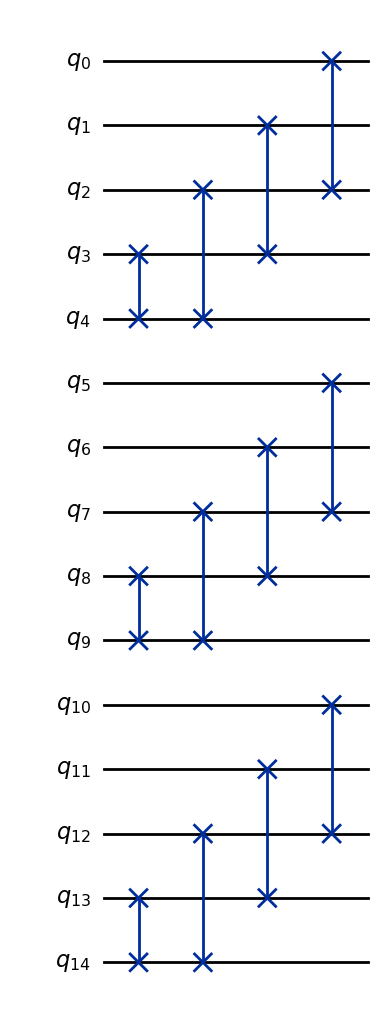

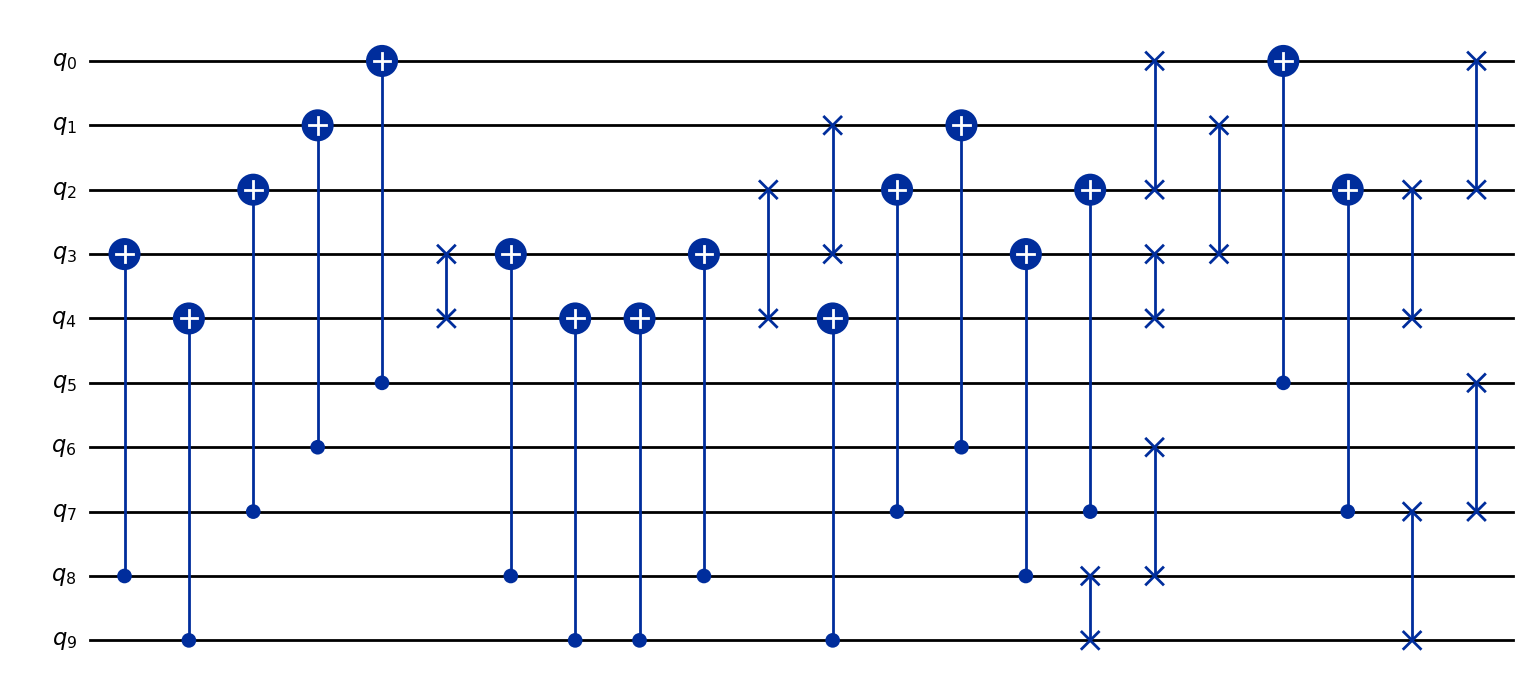

In [40]:
for _, phys_circ in circuits:
    normal_circ  = embed_circ_to_normal_circ(phys_circ, n_og, embed_codespace_dict)
    try:
        log_act = logical_circ_and_pauli_correct(H_symp, normal_circ).run()[0]
        print("embedded physical circuit:", phys_circ)
        print("normal physical circuit:  ", normal_circ)
        print("logical action:           ", log_act)
        display(construct_circuit(phys_circ, n_embedded).draw(output='mpl'))
        display(construct_circuit(normal_circ, n_og).draw(output='mpl'))
        display(construct_circuit(log_act, k).draw(output='mpl'))
        print("\n"+80*"=" +"\n")
    except:
        print("embedded physical circuit:", phys_circ)
        print("normal physical circuit:  ", normal_circ)
        print("logical action:           "+ "COULD NOT FIND (circuit doesn't map to smaller space)")
        display(construct_circuit(phys_circ, n_embedded).draw(output='mpl'))
        display(construct_circuit(normal_circ, n_og).draw(output='mpl'))
        print("\n"+80*"=" +"\n")
        continue

## More ancillas between qubits from different blocks

In [42]:
def make_random_cross_pair_embedding(n_og, num_aux=None, p=None, seed=None):
    """
    Build custom embedding matrix with:
      - first n_og rows = identity
      - extra rows = weight-2 parity rows only between first half and second half

    Example for n_og=10:
      allowed pairs are (0,5), (0,6), ..., (4,9)

    Returns:
      custom_mat
      embed_codespace_dict

    embed_codespace_dict maps:
      aux_index -> (q1, q2)
    """

    rng = random.Random(seed)

    assert n_og % 2 == 0, "n_og must be even to split into two halves"

    half = n_og // 2

    first_half  = range(half)
    second_half = range(half, n_og)

    all_pairs = list(itertools.product(first_half, second_half))

    if p is not None:
        selected_pairs = [pair for pair in all_pairs if rng.random() < p]
    elif num_aux is not None:
        selected_pairs = rng.sample(all_pairs, min(num_aux, len(all_pairs)))
    else:
        selected_pairs = all_pairs

    I = np.eye(n_og, dtype=int)

    aux_rows = []
    embed_codespace_dict = {}

    for aux_i, (a, b) in enumerate(selected_pairs, start=1):
        row = np.zeros(n_og, dtype=int)
        row[a] = 1
        row[b] = 1
        aux_rows.append(row)

        embed_codespace_dict[aux_i] = (a, b)

    if len(aux_rows) > 0:
        custom_mat = np.vstack([I, np.array(aux_rows, dtype=int)])
    else:
        custom_mat = I.copy()

    return custom_mat, embed_codespace_dict

In [48]:
custom_mat, embed_codespace_dict = make_random_cross_pair_embedding(n_og,
    num_aux=12, # there is 25 possible cominations, but the search space is big and runtime limited
)

H_symp_embedded = qec_embed_code(
    H_symp,
    embedding="custom",
    custom_embedding=custom_mat
).embed_mat()

n_embedded = H_symp_embedded.shape[1] // 2

print("custom_mat shape:", custom_mat.shape)
print("embedded H shape:", H_symp_embedded.shape)
print("n_embedded:", n_embedded)
print("aux dictionary:", embed_codespace_dict)

custom_mat shape: (22, 10)
embedded H shape: (20, 44)
n_embedded: 22
aux dictionary: {1: (0, 8), 2: (1, 7), 3: (0, 5), 4: (4, 7), 5: (2, 8), 6: (2, 7), 7: (3, 9), 8: (0, 6), 9: (3, 8), 10: (4, 5), 11: (3, 6), 12: (4, 8)}


In [49]:
G, LX, LZ, D = compute_standard_form(H_symp_embedded)

In [50]:
command_file_name    = f"magma_commands_n{n_embedded}k{k}d{d}.txt"
output_file_name     = f"magma_output_n{n_embedded}k{k}d{d}.txt"
with open(output_file_name, "w") as output_file:
        pass

# magma_obj = qec_code_auts_from_magma_with_intersection(n, k, d, H_symp_embedded)
magma_obj = qec_code_auts_from_magma(n_embedded, k, d, H_symp_embedded)
magma_obj.run(fileroot='./',save_magma_commands=True)

run_magma_online_from_file(command_file_name)
code_auts_dict = parse_magma_output(output_file_name, magma_obj)

print('Aut Group Order: ', code_auts_dict['order'])
print('Time: ', code_auts_dict['time'])
print('No of aut gens: ', len(code_auts_dict['auts']))

Run the commands on MAGMA online calculator.
Copy and save output as 'magma_output_n22k2d3.txt'

Aut Group Order:  1
Time:  8.48
No of aut gens:  0


In [ ]:
# H_3bit = np.hstack([H_symp_embedded,(H_symp_embedded[:,:n_embedded]+H_symp_embedded[:,n_embedded:])%2]) # adding XZ block 
# H_3bit = np.vstack([H_3bit,(H_3bit[0,:]+H_3bit[1,:])%2]) # adding the YYYY stabilizer
# auts = valid_clifford_auts_B_rows(H_3bit,bits_3=True) # computes graph auts that correspond to a physical Clifford operation

In [51]:
auts = code_auts_dict['auts']
circuits = []
for num, aut in enumerate(auts):
    phys_act = circ_from_aut(H_symp_embedded,aut)        
    phys_circ, _ = phys_act.circ()
    log_act, circ = logical_circ_and_pauli_correct(H_symp_embedded,phys_circ).run()
    circuits.append((log_act,circ))

In [52]:
for _, phys_circ in circuits:
    normal_circ  = embed_circ_to_normal_circ(phys_circ, n_og, embed_codespace_dict)
    try:
        log_act = logical_circ_and_pauli_correct(H_symp, normal_circ).run()[0]
        print("embedded physical circuit:", phys_circ)
        print("normal physical circuit:  ", normal_circ)
        print("logical action:           ", log_act)
        display(construct_circuit(phys_circ, n_embedded).draw(output='mpl'))
        display(construct_circuit(normal_circ, n_og).draw(output='mpl'))
        display(construct_circuit(log_act, k).draw(output='mpl'))
        print("\n"+80*"=" +"\n")
    except:
        print("embedded physical circuit:", phys_circ)
        print("normal physical circuit:  ", normal_circ)
        print("logical action:           "+ "COULD NOT FIND")
        display(construct_circuit(phys_circ, n_embedded).draw(output='mpl'))
        display(construct_circuit(normal_circ, n_og).draw(output='mpl'))
        print("\n"+80*"=" +"\n")
        continue